In [3]:
import pandas as pd
import sqlite3

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Load CSV
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Buat koneksi ke SQLite database
conn = sqlite3.connect('telco_churn.db')

# Import dataframe ke SQLite sebagai tabel
df.to_sql('telco_churn', conn, if_exists='replace', index=False)

print(f"Data imported successfully! Total rows: {len(df)}")

Data imported successfully! Total rows: 7043


In [5]:
# Test query
query = "SELECT COUNT(*) as total_rows FROM telco_churn"
result = pd.read_sql(query, conn)
print(result)

   total_rows
0        7043


In [6]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\Asus\Documents\customer-churn-analysis
['.venv', 'telco_churn.db', 'WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [12]:
# Percentage churn vs non-churn
query = """
SELECT 
    Churn,
    COUNT(*) as total,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM telco_churn), 2) as percentage
FROM telco_churn
GROUP BY Churn
"""
pd.read_sql(query, conn)

,Churn,total,percentage
0,No,5174,73.46
1,Yes,1869,26.54


In [ ]:
# Type of Contract Customer Churn
query = """
SELECT 
    Contract,
    COUNT(*) as total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as churned,
    ROUND(SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as churn_rate
FROM telco_churn
GROUP BY Contract
ORDER BY churn_rate DESC
"""
pd.read_sql(query, conn)

,Contract,total_customers,churned,churn_rate
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


In [ ]:
# Churn by Tenure
query = """
SELECT 
    CASE 
        WHEN tenure <= 12 THEN '0-12 months'
        WHEN tenure <= 24 THEN '13-24 months'
        WHEN tenure <= 48 THEN '25-48 months'
        ELSE '49+ months'
    END as tenure_group,
    COUNT(*) as total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as churned,
    ROUND(SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as churn_rate
FROM telco_churn
GROUP BY tenure_group
ORDER BY churn_rate DESC
"""
pd.read_sql(query, conn)

,tenure_group,total_customers,churned,churn_rate
0,0-12 months,2186,1037,47.44
1,13-24 months,1024,294,28.71
2,25-48 months,1594,325,20.39
3,49+ months,2239,213,9.51


In [ ]:
# Churn by Gender
query = """
SELECT 
    gender,
    COUNT(*) as total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) as churned,
    ROUND(SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as churn_rate
FROM telco_churn
GROUP BY gender
ORDER BY churn_rate DESC
"""
pd.read_sql(query, conn)

,gender,total_customers,churned,churn_rate
0,Female,3488,939,26.92
1,Male,3555,930,26.16


In [ ]:
# Monthly Charges
query = """
SELECT 
    Churn,
    ROUND(AVG(MonthlyCharges), 2) as avg_monthly_charges,
    ROUND(AVG(tenure), 2) as avg_tenure_months
FROM telco_churn
GROUP BY Churn
"""
pd.read_sql(query, conn)

,Churn,avg_monthly_charges,avg_tenure_months
0,No,61.27,37.57
1,Yes,74.44,17.98


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

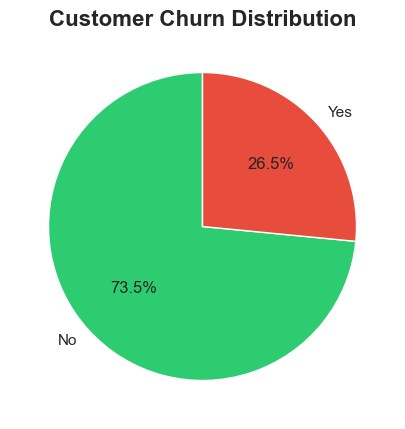

In [16]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(7, 5))
colors = ['#2ecc71', '#e74c3c']
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Customer Churn Distribution', fontsize=16, fontweight='bold')
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_23520\3077181228.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=contract_churn, x='Contract', y='Churn Rate',


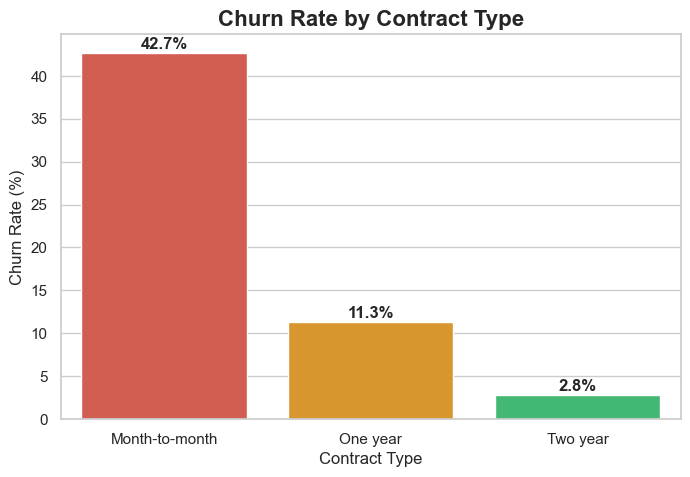

In [17]:
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
contract_churn.columns = ['Contract', 'Churn Rate']

plt.figure(figsize=(8, 5))
bars = sns.barplot(data=contract_churn, x='Contract', y='Churn Rate',
                   palette=['#e74c3c', '#f39c12', '#2ecc71'])
plt.title('Churn Rate by Contract Type', fontsize=16, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')
for bar, val in zip(bars.patches, contract_churn['Churn Rate']):
    bars.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
              f'{val:.1f}%', ha='center', fontweight='bold')
plt.savefig('churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_23520\468795473.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tenure_churn, x='Tenure Group', y='Churn Rate',


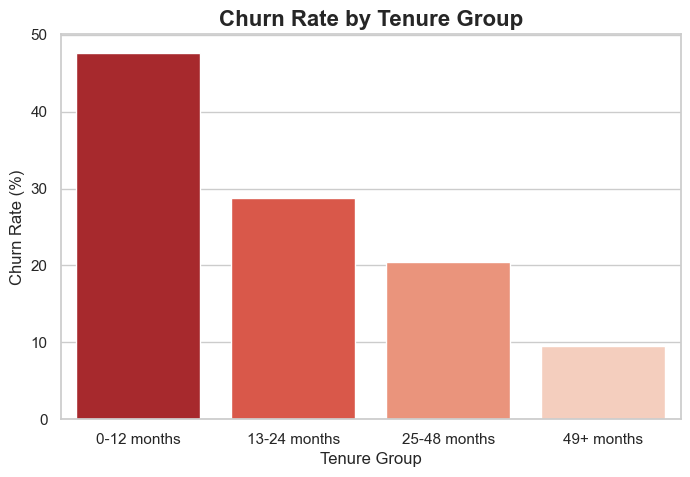

In [18]:
df['tenure_group'] = pd.cut(df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '49+ months'])

tenure_churn = df.groupby('tenure_group')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
tenure_churn.columns = ['Tenure Group', 'Churn Rate']

plt.figure(figsize=(8, 5))
sns.barplot(data=tenure_churn, x='Tenure Group', y='Churn Rate',
            palette='Reds_r')
plt.title('Churn Rate by Tenure Group', fontsize=16, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Tenure Group')
plt.savefig('churn_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_23520\608255618.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges',


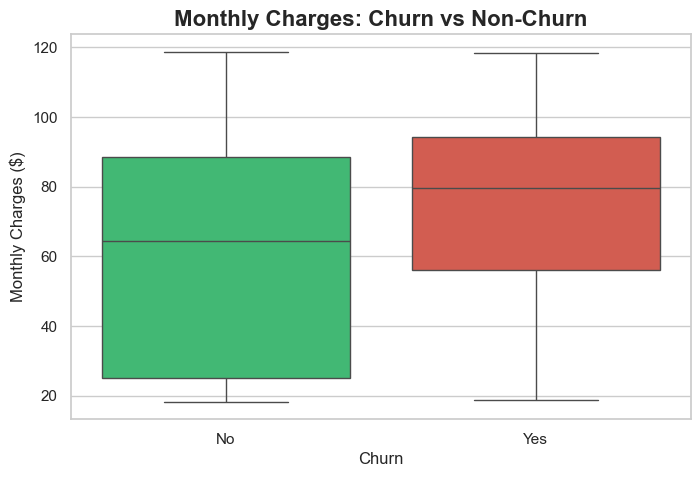

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
            palette={'No': '#2ecc71', 'Yes': '#e74c3c'})
plt.title('Monthly Charges: Churn vs Non-Churn', fontsize=16, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.savefig('monthly_charges_churn.png', dpi=150, bbox_inches='tight')
plt.show()